# Proportion of unspliced RNAs

In [1]:
import glob
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt

In [38]:
def load_unsplice_ratio(path):
    d = pd.read_csv(path, sep="\t")
    n = d[["Spliced", "Unspliced", "Ambiguity", "Unknown"]].sum(axis=1).values[0]
    v1, v2, v3 = d["UnsplicedRatio"].values * 100 # All, New, Old
    return n, v1, v2, v3

In [39]:
data = []

In [40]:
# RNA-seq (ActD)

vs = []
for path in sorted(glob.glob("../../../3_RNAseq_ActD/results/04_stat/01_read_location/*_summary.tsv")):
    n, p1, p2, p3 = load_unsplice_ratio(path)
    print(n, p1, p2, p3)
    vs.append(p1)
data.append(["RNA-seq.ActD0h", "All", vs[0:2]])
data.append(["RNA-seq.ActD3h", "All", vs[2:4]])
data.append(["RNA-seq.ActD6h", "All", vs[4:6]])

18726696 10.35126913543698 nan 10.35126913543698
19178134 10.2329835667965 nan 10.2329835667965
21216211 6.39447123043555 nan 6.39447123043555
19686805 6.35933915501498 nan 6.35933915501498
18834679 5.45763001880439 nan 5.45763001880439
21082809 5.64218830054077 nan 5.64218830054077


In [41]:
# PRO-seq and TT-seq

vs = []
for path in sorted(glob.glob("../../../others/01_PROseq_K562/results.old/04_stat/01_read_location/*_summary.tsv")):
    print(path)
    n, p1, p2, p3 = load_unsplice_ratio(path)
    print(n, p1, p2, p3)
    vs.append(p1)
data.append(["PRO-seq", "New", vs])

vs = []
for path in sorted(glob.glob("../../../others/02_TTseq_K562/results/04_stat/01_read_location/*_summary.tsv")):
    if "control_TTseq" in path:
        continue
    print(path)
    n, p1, p2, p3 = load_unsplice_ratio(path)
    print(n, p1, p2, p3)
    vs.append(p1)
data.append(["TT-seq", "New", vs])

../../../others/01_PROseq_K562/results.old/04_stat/01_read_location/GSM1480327_K562_PROseq_summary.tsv
377111986 99.97715450547392 nan 99.97715450547392
../../../others/01_PROseq_K562/results.old/04_stat/01_read_location/GSM2361442_K562_PROseq_NHS_Rep1_summary.tsv
65847619 99.927563043713 nan 99.927563043713
../../../others/01_PROseq_K562/results.old/04_stat/01_read_location/GSM2361443_K562_PROseq_NHS_Rep2_summary.tsv
23130062 99.94900887266695 nan 99.94900887266695
../../../others/01_PROseq_K562/results.old/04_stat/01_read_location/GSM2545324_K562_PROseq_preseq_0min_plus_rep1_summary.tsv
26276552 99.9393329108114 nan 99.9393329108114
../../../others/01_PROseq_K562/results.old/04_stat/01_read_location/GSM2545325_K562_PROseq_preseq_0min_plus_rep2_summary.tsv
27033804 99.94238348660625 nan 99.94238348660625
../../../others/01_PROseq_K562/results.old/04_stat/01_read_location/GSM3452725_K562_PROseq_summary.tsv
61812634 99.91856059275436 nan 99.91856059275436
../../../others/02_TTseq_K562/r

In [42]:
# NASC-seq (NCBI)

vs1 = []
vs2 = []
vs3 = []
for path in sorted(glob.glob("../../../2_NASCseq/results/05_stat/02_read_location/GSE128273_NASCseq_SE/*.K562_s4U_0uM_180min_summary.tsv")):
    n, p1, p2, p3 = load_unsplice_ratio(path)
    if n > 100000:
        vs1.append(p1)
        vs2.append(p2)
        vs3.append(p3)
print(len(vs1))
data.append(["Public.NASC-seq.0uM0min", "All", vs1])
#data.append(["Public.NASC-seq.0uM0min", "New", vs2])
#data.append(["Public.NASC-seq.0uM0min", "Old", vs3])

for time in [15, 60, 180]:
    vs1 = []
    vs2 = []
    vs3 = []
    for path in sorted(glob.glob("../../../2_NASCseq/results/05_stat/02_read_location/GSE128273_NASCseq*/*.K562_s4U_50uM_%smin_summary.tsv" % time)):
        n, p1, p2, p3 = load_unsplice_ratio(path)
        if n > 100000:
            vs1.append(p1)
            vs2.append(p2)
            vs3.append(p3)
    print(len(vs1))
    data.append(["Public.NASC-seq.50uM%dmin" % time, "All", vs1])
    data.append(["Public.NASC-seq.50uM%dmin" % time, "New", vs2])
    data.append(["Public.NASC-seq.50uM%dmin" % time, "Old", vs3])

14
45
126
79


In [43]:
# NASC-seq (Tanglab)

vs1 = []
vs2 = []
vs3 = []
for path in sorted(glob.glob("../../../2_NASCseq/results/05_stat/02_read_location/2022*_NASCseq//*.K562_s4U_0uM_180min_summary.tsv")):
    n, p1, p2, p3 = load_unsplice_ratio(path)
    if n > 100000:
        vs1.append(p1)
        vs2.append(p2)
        vs3.append(p3)
print(len(vs1))
data.append(["NASC-seq.0uM0min", "All", vs1])
#data.append(["NASC-seq.0uM0min", "New", vs2])
#data.append(["NASC-seq.0uM0min", "Old", vs3])

for time in [120, 180]:
    vs1 = []
    vs2 = []
    vs3 = []
    for path in sorted(glob.glob("../../../2_NASCseq/results/05_stat/02_read_location/2022*_NASCseq/*.K562_s4U_50uM_%smin_summary.tsv" % time)):
        n, p1, p2, p3 = load_unsplice_ratio(path)
        if n > 100000:
            vs1.append(p1)
            vs2.append(p2)
            vs3.append(p3)
    print(len(vs1))
    data.append(["NASC-seq.50uM%dmin" % time, "All", vs1])
    data.append(["NASC-seq.50uM%dmin" % time, "New", vs2])
    data.append(["NASC-seq.50uM%dmin" % time, "Old", vs3])

39
10
38


In [44]:
# SCAN-seq2

vs = []
for path in glob.glob("../../../others/05_SCANseq2/results/05_stat/01_read_location/*/*_Human_K562_summary.tsv"):
    n, p1, p2, p3 = load_unsplice_ratio(path)
    if n >= 100000:
        vs.append(p1)
print(len(vs))
data.append(["SCAN-seq2", "All", vs])

136


In [45]:
# Nano-COP

vs = []
for path in sorted(glob.glob("../../../others/09_NanoCOP_GSE123191/results/02_stat/01_read_location/*_summary.tsv")):
    if "noA" not in path:
        print(path)
        n, p1, p2, p3 = load_unsplice_ratio(path)
        vs.append(p1)
data.append(["Nano-COP", "New", vs])

../../../others/09_NanoCOP_GSE123191/results/02_stat/01_read_location/K562_4sUchr_ONT_1_summary.tsv
../../../others/09_NanoCOP_GSE123191/results/02_stat/01_read_location/K562_4sUchr_ONT_2_summary.tsv
../../../others/09_NanoCOP_GSE123191/results/02_stat/01_read_location/K562_4sUchr_ONT_3_summary.tsv


In [46]:
# NanoNASC-seq

vs1 = []
vs2 = []
vs3 = []
for path in sorted(glob.glob("../../../1_NanoNASCseq/results/09_stat/01_read_location/*/*.K562_s4U_0uM_180min_summary.tsv")):
    n, p1, p2, p3 = load_unsplice_ratio(path)
    if n > 5000:
        vs1.append(p1)
        vs2.append(p2)
        vs3.append(p3)
print(len(vs1))
data.append(["NanoNASC-seq.0uM0min", "All", vs1])
# data.append(["NanoNASC-seq.0uM0min", "New", vs2])
# data.append(["NanoNASC-seq.0uM0min", "Old", vs3])

for time in [15, 30, 60, 120, 180]:
    vs1 = []
    vs2 = []
    vs3 = []
    for path in sorted(glob.glob("../../../1_NanoNASCseq/results/09_stat/01_read_location/*/*.K562_s4U_50uM_%dmin_summary.tsv" % time)):
        if "Mix" in path:
            continue
        n, p1, p2, p3 = load_unsplice_ratio(path)
        if n > 5000:
            vs1.append(p1)
            vs2.append(p2)
            vs3.append(p3)
    print(len(vs1))
    data.append(["NanoNASC-seq.50uM%dmin" % time, "All", vs1])
    data.append(["NanoNASC-seq.50uM%dmin" % time, "New", vs2])
    data.append(["NanoNASC-seq.50uM%dmin" % time, "Old", vs3])

166
32
48
34
39
134


In [47]:
for time in [180]:
    for s4u in [100, 200, 400, 500]:
        vs1 = []
        vs2 = []
        vs3 = []
        for path in sorted(glob.glob("../../../1_NanoNASCseq/results/09_stat/01_read_location/*/*.K562_s4U_%duM_%dmin_summary.tsv" % (s4u, time))):
            if "Mix" in path:
                continue
            n, p1, p2, p3 = load_unsplice_ratio(path)
            if n > 3000:
                vs1.append(p1)
                vs2.append(p2)
                vs3.append(p3)
        print(s4u, time, len(vs1))
        data.append(["NanoNASC-seq.%duM%dmin" % (s4u, time), "All", vs1])
        data.append(["NanoNASC-seq.%duM%dmin" % (s4u, time), "New", vs2])
        data.append(["NanoNASC-seq.%duM%dmin" % (s4u, time), "Old", vs3])

100 180 17
200 180 9
400 180 16
500 180 23


In [48]:
# NanoNASC-seq (K562-FUCCI)
info = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")
d = info[(info["CellLine"] == "K562_FUCCI") & (info["s4U"] == 50) & (info["Time"] == 3) & (info["UMIs"] > 5000)]
d1 = d[[c.endswith("_G1") for c in d["Cell"]]]
d2 = d[np.array([c.endswith("_S") for c in d["Cell"]]) & np.array(["early" in x.lower() for x in d["Remark"]])]
d3 = d[np.array([c.endswith("_S") for c in d["Cell"]]) & np.array(["early" not in x.lower() for x in d["Remark"]])]
d4 = d[[c.endswith("_G2M") for c in d["Cell"]]]
d1.shape, d2.shape, d3.shape, d4.shape
phase_list = ["G1", "S1", "S2", "G2M"]
s4u, time = 50, 180
for phase, d in zip(phase_list, [d1, d2, d3, d4]):
    vs1 = []
    vs2 = []
    vs3 = []
    for cell in d["Cell"]:
        path = "../../../1_NanoNASCseq/results/09_stat/01_read_location/%s/%s_summary.tsv" % (cell.split(".")[0], cell)
        n, p1, p2, p3 = load_unsplice_ratio(path)
        if n > 3000:
            vs1.append(p1)
            vs2.append(p2)
            vs3.append(p3)
    print(phase, len(vs1))
    data.append(["NanoNASC-seq.%s.%duM%dmin" % (phase, s4u, time), "All", vs1])
    data.append(["NanoNASC-seq.%s.%duM%dmin" % (phase, s4u, time), "New", vs2])
    data.append(["NanoNASC-seq.%s.%duM%dmin" % (phase, s4u, time), "Old", vs3])

G1 202
S1 197
S2 236
G2M 260


In [49]:
# NanoNASC-seq (mESC)

for s4u in [0, 50, 400]:
    vs1 = []
    vs2 = []
    vs3 = []
    for path in sorted(glob.glob("../../../1_NanoNASCseq/results/09_stat/01_read_location/*/*.mESC_s4U_%duM_180min_summary.tsv" % s4u)):
        n, p1, p2, p3 = load_unsplice_ratio(path)
        if n > 5000:
            vs1.append(p1)
            vs2.append(p2)
            vs3.append(p3)
    print(len(vs1))
    data.append(["NanoNASC-seq.mESC.%duM180min" % s4u, "All", vs1])
    if s4u > 0:
        data.append(["NanoNASC-seq.mESC.%duM180min" % s4u, "New", vs2])
        data.append(["NanoNASC-seq.mESC.%duM180min" % s4u, "Old", vs3])

60
60
135


In [50]:
# scCOLOR-seq

vs = []
for path in glob.glob("../../../others/06_scCOLORseq/results/04_stat/01_read_location/*.tsv"):
    n, p1, p2, p3 = load_unsplice_ratio(path)
    if n >= 100000:
        vs.append(p1)
print(len(vs))
data.append(["scCOLOR-seq", "All", vs])

6


In [51]:
# scNT-seq

vs = []
for path in glob.glob("../../../A07_GSE141851_scNTseq/results/06_stat/02_read_location/*.tsv"):
    n, p1, p2, p3 = load_unsplice_ratio(path)
    if n >= 100000:
        vs.append(p1)
print(len(vs))
data.append(["scNT-seq", "All", vs])

# Well-TEMP-seq

vs = []
for path in glob.glob("../../../A12_GSE194357_WellTEMPseq/results/04_stat/02_read_location/*.tsv"):
    n, p1, p2, p3 = load_unsplice_ratio(path)
    if n >= 100000:
        vs.append(p1)
print(len(vs))
data.append(["Well-TEMP-seq", "All", vs])

0
0


In [52]:
# rows = []
# for item in data:
#     rows.append([item[0], item[1], np.median(item[2]), np.mean(item[2])])
# m = pd.DataFrame(rows, columns=["Name", "Group", "Median", "Mean"])
# m

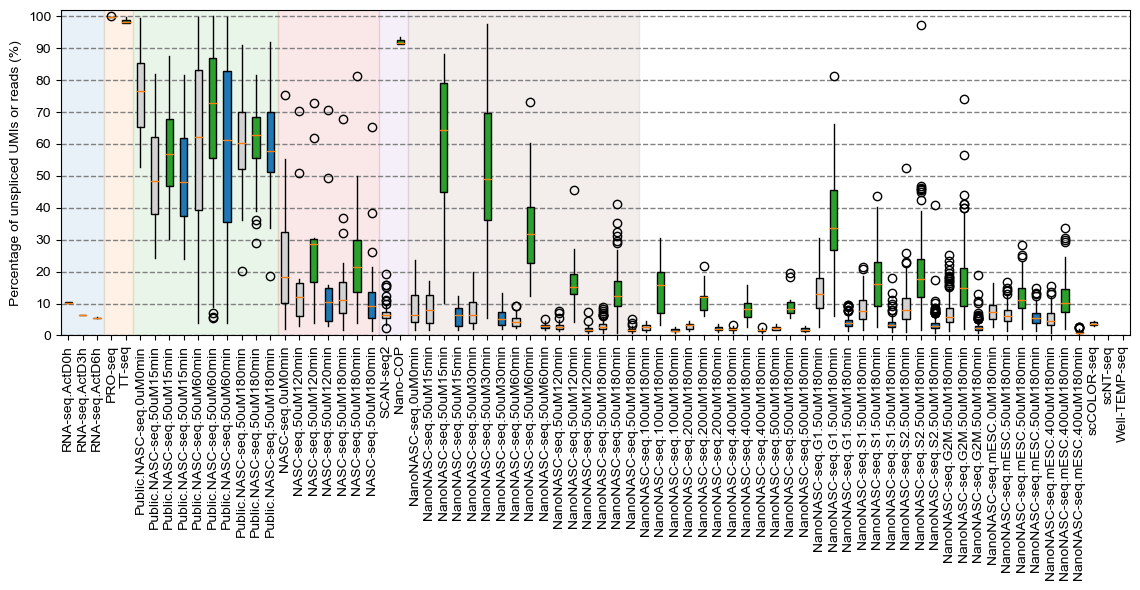

In [53]:
xs = np.arange(len(data))
xticks = [item[0] for item in data]
w = 0.5
plt.figure(figsize=(11.5, 6))
for x, item in zip(xs, data):
    name, group, vs = item
    if group == "New":
        color = "C2"
    elif group == "Old":
        color = "C0"
    else:
        color = "lightgrey"
    plt.boxplot([vs], positions=[x], widths=w, showcaps=False, showfliers=True,
                patch_artist=True, boxprops=dict(facecolor=color))
plt.axvspan(-0.5, 2.5, color="C0", alpha=0.1)
plt.axvspan(2.5, 4.5, color="C1", alpha=0.1)
plt.axvspan(4.5, 14.5, color="C2", alpha=0.1)
plt.axvspan(14.5, 21.5, color="C3", alpha=0.1)
plt.axvspan(21.5, 23.5, color="C4", alpha=0.1)
plt.axvspan(23.5, 39.5, color="C5", alpha=0.1)
# plt.xticks([])
plt.xticks(xs, xticks, rotation=90)
# plt.xticks(xs, [item[1][0] for item in data], rotation=0, size=10)
plt.ylim(0, 102)
plt.yticks(np.arange(0, 101, 10))
plt.grid(axis="y", color="grey", lw=1, ls="--")
plt.ylabel("Percentage of unspliced UMIs or reads (%)")
plt.tight_layout()
# plt.savefig("figures/proportion_of_unspliced_reads.pdf")
plt.show()
plt.close()

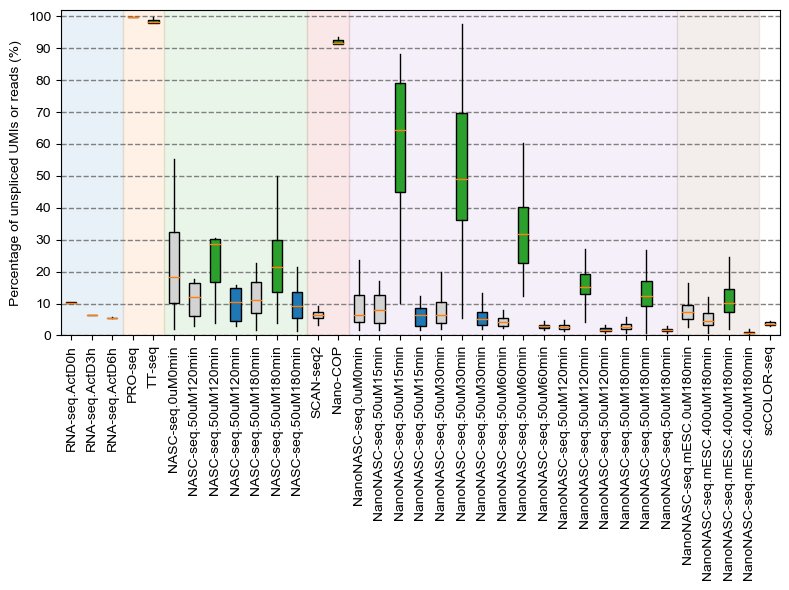

In [58]:
# 
selected = []
for item in data:
    selected.append(item[0])
selected

selected = [
    'RNA-seq.ActD0h',
    'RNA-seq.ActD3h',
    'RNA-seq.ActD6h',
    'PRO-seq',
    'TT-seq',
    # 'Public.NASC-seq.0uM0min',
    # 'Public.NASC-seq.50uM15min',
    # 'Public.NASC-seq.50uM15min',
    # 'Public.NASC-seq.50uM15min',
    # 'Public.NASC-seq.50uM60min',
    # 'Public.NASC-seq.50uM60min',
    # 'Public.NASC-seq.50uM60min',
    # 'Public.NASC-seq.50uM180min',
    # 'Public.NASC-seq.50uM180min',
    # 'Public.NASC-seq.50uM180min',
    'NASC-seq.0uM0min',
    'NASC-seq.50uM120min',
    'NASC-seq.50uM120min',
    'NASC-seq.50uM120min',
    'NASC-seq.50uM180min',
    'NASC-seq.50uM180min',
    'NASC-seq.50uM180min',
    'SCAN-seq2',
    'Nano-COP',
    'NanoNASC-seq.0uM0min',
    'NanoNASC-seq.50uM15min',
    'NanoNASC-seq.50uM15min',
    'NanoNASC-seq.50uM15min',
    'NanoNASC-seq.50uM30min',
    'NanoNASC-seq.50uM30min',
    'NanoNASC-seq.50uM30min',
    'NanoNASC-seq.50uM60min',
    'NanoNASC-seq.50uM60min',
    'NanoNASC-seq.50uM60min',
    'NanoNASC-seq.50uM120min',
    'NanoNASC-seq.50uM120min',
    'NanoNASC-seq.50uM120min',
    'NanoNASC-seq.50uM180min',
    'NanoNASC-seq.50uM180min',
    'NanoNASC-seq.50uM180min',
    # 'NanoNASC-seq.100uM180min',
    # 'NanoNASC-seq.100uM180min',
    # 'NanoNASC-seq.100uM180min',
    # 'NanoNASC-seq.200uM180min',
    # 'NanoNASC-seq.200uM180min',
    # 'NanoNASC-seq.200uM180min',
    # 'NanoNASC-seq.400uM180min',
    # 'NanoNASC-seq.400uM180min',
    # 'NanoNASC-seq.400uM180min',
    # 'NanoNASC-seq.500uM180min',
    # 'NanoNASC-seq.500uM180min',
    # 'NanoNASC-seq.500uM180min',
    'NanoNASC-seq.mESC.0uM180min',
    # 'NanoNASC-seq.mESC.50uM180min',
    # 'NanoNASC-seq.mESC.50uM180min',
    # 'NanoNASC-seq.mESC.50uM180min',
    'NanoNASC-seq.mESC.400uM180min',
    'NanoNASC-seq.mESC.400uM180min',
    'NanoNASC-seq.mESC.400uM180min',
    'scCOLOR-seq',
    # 'scNT-seq',
    # 'Well-TEMP-seq'
]

data2 = list(filter(lambda item: item[0] in selected, data))

xs = np.arange(len(data2))
xticks = [item[0] for item in data2]
w = 0.5
plt.figure(figsize=(8, 6))
for x, item in zip(xs, data2):
    name, group, vs = item
    if group == "New":
        color = "C2"
    elif group == "Old":
        color = "C0"
    else:
        color = "lightgrey"
    plt.boxplot([vs], positions=[x], widths=w, showcaps=False, showfliers=False,
                patch_artist=True, boxprops=dict(facecolor=color))
plt.axvspan(-0.5, 2.5, color="C0", alpha=0.1)
plt.axvspan(2.5, 4.5, color="C1", alpha=0.1)
plt.axvspan(4.5, 11.5, color="C2", alpha=0.1)
plt.axvspan(11.5, 13.5, color="C3", alpha=0.1)
plt.axvspan(13.5, 29.5, color="C4", alpha=0.1)
plt.axvspan(29.5, 33.5, color="C5", alpha=0.1)
# plt.xticks([])
plt.xticks(xs, xticks, rotation=90)
# plt.xticks(xs, [item[1][0] for item in data], rotation=0, size=10)
plt.ylim(0, 102)
plt.yticks(np.arange(0, 101, 10))
plt.grid(axis="y", color="grey", lw=1, ls="--")
plt.ylabel("Percentage of unspliced UMIs or reads (%)")
plt.tight_layout()
plt.savefig("figures/proportion_of_unspliced_reads.pdf")
plt.show()
plt.close()

In [59]:
print("Name\tGroup\tMedian\tMean")
for item in data2:
    print(item[0], item[1], np.median(item[2]), np.mean(item[2]), sep="\t")

Name	Group	Median	Mean
RNA-seq.ActD0h	All	10.292126351116739	10.292126351116739
RNA-seq.ActD3h	All	6.376905192725265	6.376905192725265
RNA-seq.ActD6h	All	5.5499091596725805	5.5499091596725805
PRO-seq	New	99.94085819870882	99.94233390200431
TT-seq	New	98.24123606981011	98.51297348800873
NASC-seq.0uM0min	All	18.312989564616032	22.191760017701725
NASC-seq.50uM120min	All	12.17090850703169	19.828126259698653
NASC-seq.50uM120min	New	28.64125295725416	30.667340780416218
NASC-seq.50uM120min	Old	10.46742732016087	18.5817861545168
NASC-seq.50uM180min	All	10.991732114537221	13.740407042707227
NASC-seq.50uM180min	New	21.341087434105315	24.161822859148906
NASC-seq.50uM180min	Old	9.344640409832934	11.546201980585858
SCAN-seq2	All	6.387741637584145	6.7621602262116784
Nano-COP	New	91.53519198904978	92.06022510546086
NanoNASC-seq.0uM0min	All	6.52771159356271	8.794665973682166
NanoNASC-seq.50uM15min	All	7.8870270583207045	8.373712709676138
NanoNASC-seq.50uM15min	New	64.41612048941427	60.483119820059855


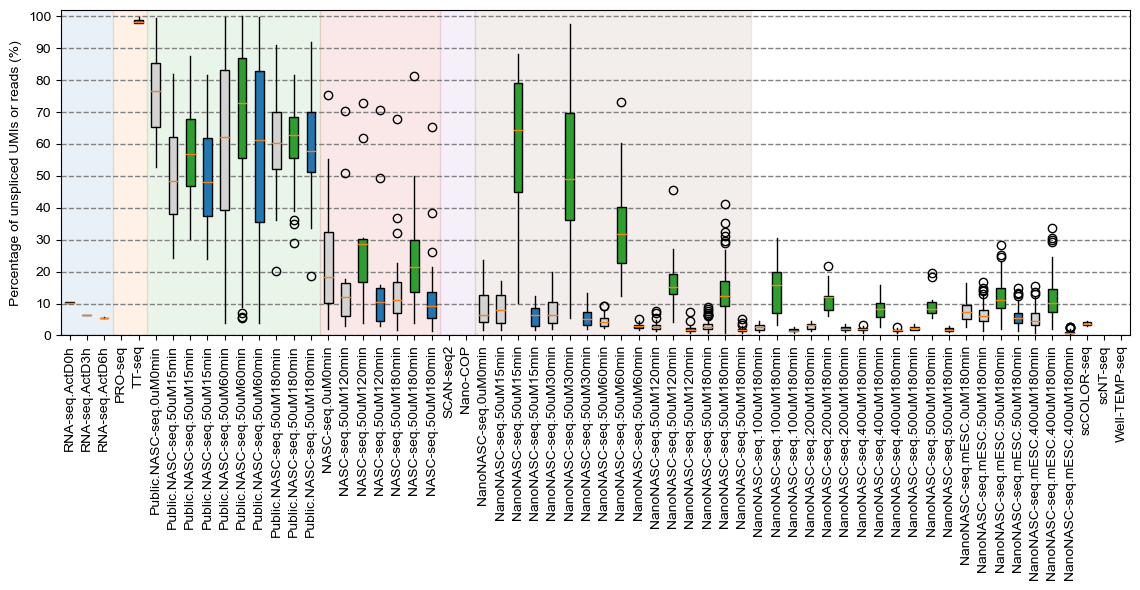

In [19]:
xs = np.arange(len(data))
xticks = [item[0] for item in data]
w = 0.5
plt.figure(figsize=(11.5, 6))
for x, item in zip(xs, data):
    name, group, vs = item
    if group == "New":
        color = "C2"
    elif group == "Old":
        color = "C0"
    else:
        color = "lightgrey"
    plt.boxplot([vs], positions=[x], widths=w, showcaps=False, showfliers=True,
                patch_artist=True, boxprops=dict(facecolor=color))
plt.axvspan(-0.5, 2.5, color="C0", alpha=0.1)
plt.axvspan(2.5, 4.5, color="C1", alpha=0.1)
plt.axvspan(4.5, 14.5, color="C2", alpha=0.1)
plt.axvspan(14.5, 21.5, color="C3", alpha=0.1)
plt.axvspan(21.5, 23.5, color="C4", alpha=0.1)
plt.axvspan(23.5, 39.5, color="C5", alpha=0.1)
# plt.xticks([])
plt.xticks(xs, xticks, rotation=90)
# plt.xticks(xs, [item[1][0] for item in data], rotation=0, size=10)
plt.ylim(0, 102)
plt.yticks(np.arange(0, 101, 10))
plt.grid(axis="y", color="grey", lw=1, ls="--")
plt.ylabel("Percentage of unspliced UMIs or reads (%)")
plt.tight_layout()
# plt.savefig("figures/proportion_of_unspliced_reads.pdf")

In [20]:
xticks

['RNA-seq.ActD0h',
 'RNA-seq.ActD3h',
 'RNA-seq.ActD6h',
 'PRO-seq',
 'TT-seq',
 'Public.NASC-seq.0uM0min',
 'Public.NASC-seq.50uM15min',
 'Public.NASC-seq.50uM15min',
 'Public.NASC-seq.50uM15min',
 'Public.NASC-seq.50uM60min',
 'Public.NASC-seq.50uM60min',
 'Public.NASC-seq.50uM60min',
 'Public.NASC-seq.50uM180min',
 'Public.NASC-seq.50uM180min',
 'Public.NASC-seq.50uM180min',
 'NASC-seq.0uM0min',
 'NASC-seq.50uM120min',
 'NASC-seq.50uM120min',
 'NASC-seq.50uM120min',
 'NASC-seq.50uM180min',
 'NASC-seq.50uM180min',
 'NASC-seq.50uM180min',
 'SCAN-seq2',
 'Nano-COP',
 'NanoNASC-seq.0uM0min',
 'NanoNASC-seq.50uM15min',
 'NanoNASC-seq.50uM15min',
 'NanoNASC-seq.50uM15min',
 'NanoNASC-seq.50uM30min',
 'NanoNASC-seq.50uM30min',
 'NanoNASC-seq.50uM30min',
 'NanoNASC-seq.50uM60min',
 'NanoNASC-seq.50uM60min',
 'NanoNASC-seq.50uM60min',
 'NanoNASC-seq.50uM120min',
 'NanoNASC-seq.50uM120min',
 'NanoNASC-seq.50uM120min',
 'NanoNASC-seq.50uM180min',
 'NanoNASC-seq.50uM180min',
 'NanoNASC-seq.50uM

0.05 1.3010299956639813


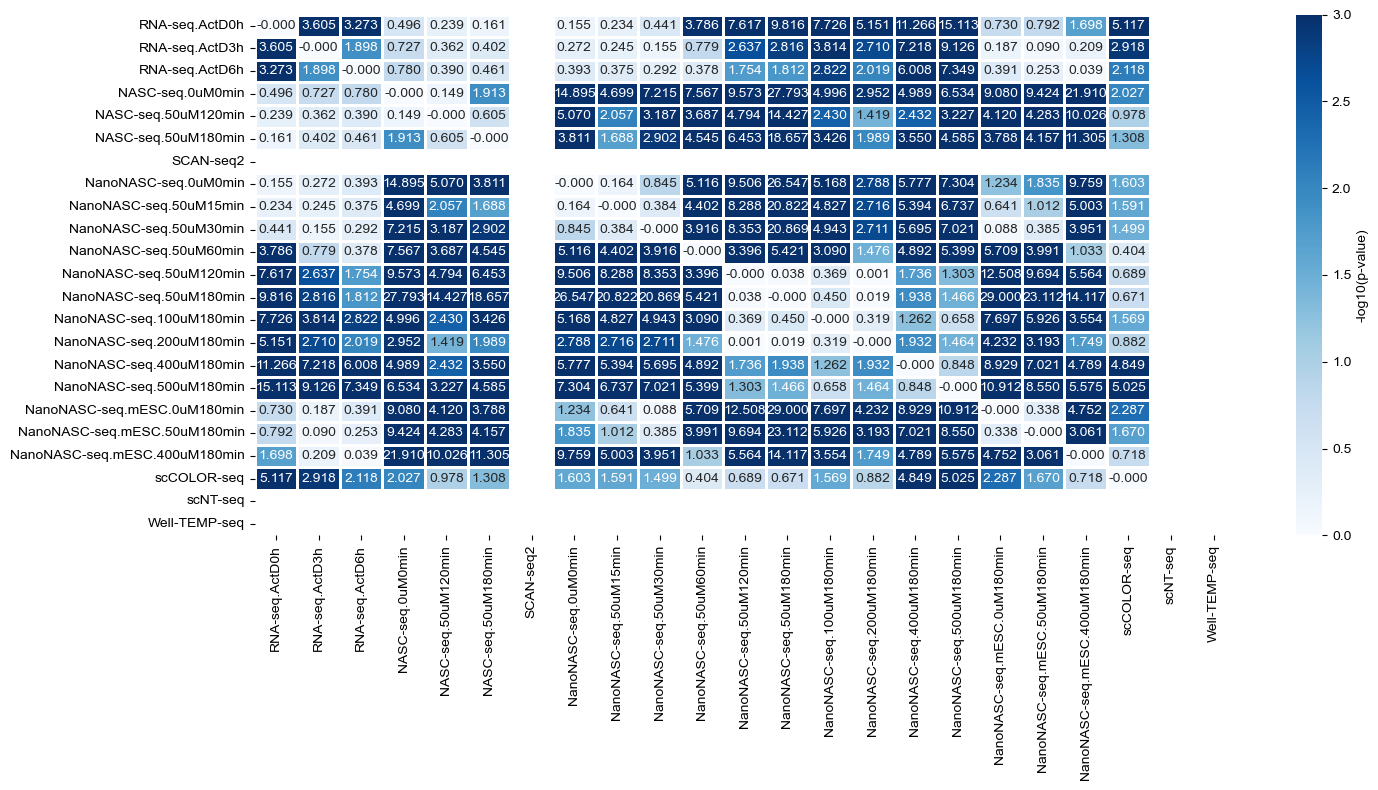

In [21]:
data1 = []
for item in data:
    if item[0].startswith("Public"):
        continue
    if item[1] == "All":
        data1.append(item)

names = [item[0] for item in data1]
M = np.zeros((len(data1), len(data1)))
for i in range(len(data1)):
    for j in range(len(data1)):
        vs1 = data1[i][2]
        vs2 = data1[j][2]
        M[i][j] = ttest_ind(vs1, vs2)[1]
M = pd.DataFrame(M, index=names, columns=names)

import seaborn as sns
print(0.05, -np.log10(0.05))
plt.figure(figsize=(15, 8))
sns.heatmap(-np.log10(M), cmap="Blues", annot=True, fmt=".3f", vmin=0, vmax=3, lw=1, color="white", cbar_kws=dict(label="-log10(p-value)"))
plt.tight_layout()
plt.savefig("figures/ttest_unpliced_ratio.all.pdf")

0.05 1.3010299956639813


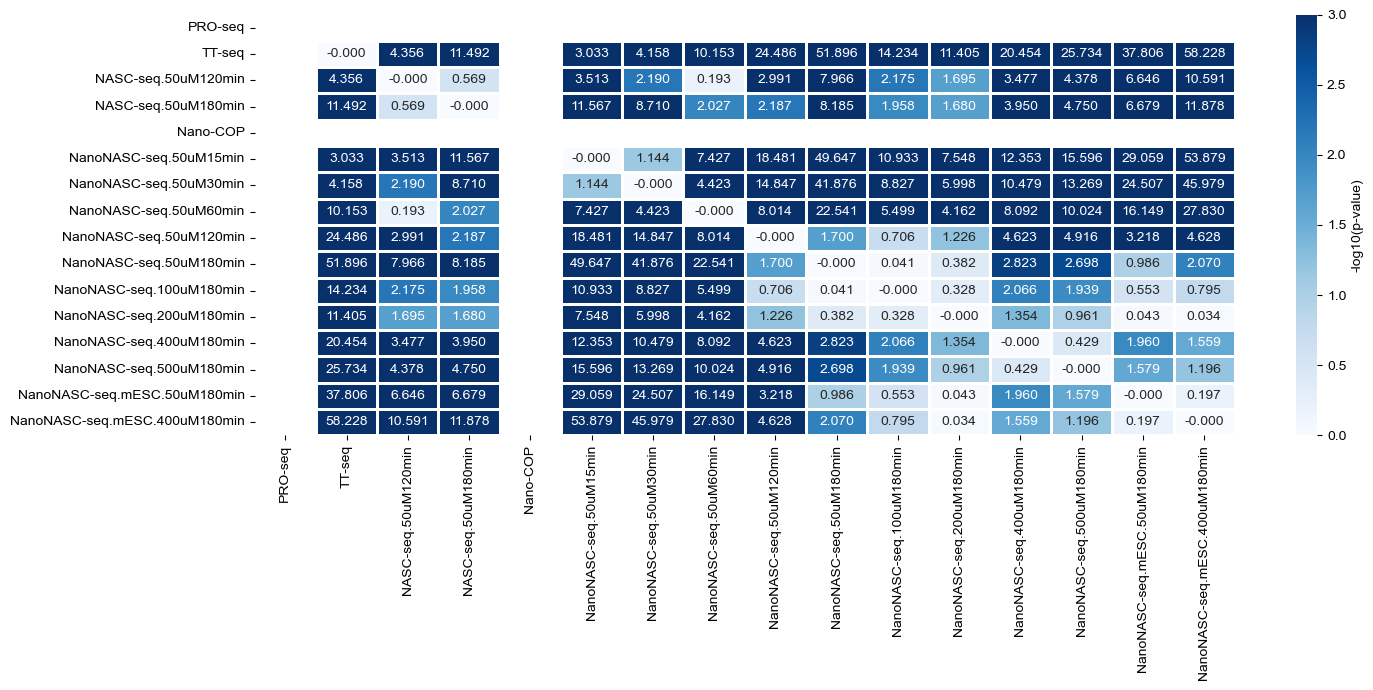

In [22]:
data1 = []
for item in data:
    if item[0].startswith("Public"):
        continue
    if item[1] == "New":
        data1.append(item)

names = [item[0] for item in data1]
M = np.zeros((len(data1), len(data1)))
for i in range(len(data1)):
    for j in range(len(data1)):
        vs1 = data1[i][2]
        vs2 = data1[j][2]
        M[i][j] = ttest_ind(vs1, vs2)[1]
M = pd.DataFrame(M, index=names, columns=names)

import seaborn as sns
print(0.05, -np.log10(0.05))
plt.figure(figsize=(15, 7))
sns.heatmap(-np.log10(M), cmap="Blues", annot=True, fmt=".3f", vmin=0, vmax=3, lw=1, color="white", cbar_kws=dict(label="-log10(p-value)"))
plt.tight_layout()
plt.savefig("figures/ttest_unpliced_ratio.new.pdf")

# Proportion of unspliced RNAs (K562-FUCCI)

In [21]:
data = []

info = pd.read_csv("../19_fucci/results/NanoNASCseq_FUCCI_filtered.tsv", sep="\t", index_col=0)

groups = [
    '0uM_180min_G1',
    '0uM_180min_S1',
    '0uM_180min_S2',
    '0uM_180min_G2M',
    '50uM_120min_G1',
    '50uM_180min_G1',
    '50uM_180min_S1',
    '50uM_180min_S2',
    '50uM_180min_G2M',
]

for group in groups:
    tmp = info[info["Group"] == group]
    vs1 = []
    vs2 = []
    vs3 = []
    for cell in tmp.index:
        path = "../../1_NanoNASCseq/results/09_stat/01_read_location/%s/%s_summary.tsv" % (cell.split(".")[0], cell)
        n, p1, p2, p3 = load_unsplice_ratio(path)
        if n > 5000:
            vs1.append(p1)
            vs2.append(p2)
            vs3.append(p3)
    print(len(vs1))
    data.append(["FUCCI.%s"% group, "All", vs1])
    data.append(["FUCCI.%s"% group, "New", vs2])
    data.append(["FUCCI.%s"% group, "Old", vs3])

38
37
26
18
52
157
176
210
253


In [22]:
info = pd.read_csv("../20_exosome/results/NanoNASCseq_Exosome.tsv", sep="\t", index_col=0)

groups = [
    's4U0uM3hAID0h',
    's4U0uM3hAID4h',
    's4U0uM3hAID12h',
    's4U400uM1hAID0h',
    's4U400uM1hAID4h',
    's4U400uM1hAID12h',
    's4U400uM3hAID0h',
    's4U400uM3hAID4h',
    's4U400uM3hAID12h',
]

for group in groups:
    tmp = info[info["Group"] == group]
    vs1 = []
    vs2 = []
    vs3 = []
    for cell in tmp.index:
        path = "../../1_NanoNASCseq/results/09_stat/01_read_location/%s/%s_summary.tsv" % (cell.split(".")[0], cell)
        n, p1, p2, p3 = load_unsplice_ratio(path)
        if n > 5000:
            vs1.append(p1)
            vs2.append(p2)
            vs3.append(p3)
    print(len(vs1))
    data.append(["Exosome.%s"% group, "All", vs1])
    data.append(["Exosome.%s"% group, "New", vs2])
    data.append(["Exosome.%s"% group, "Old", vs3])

17
15
32
179
186
146
183
171
131


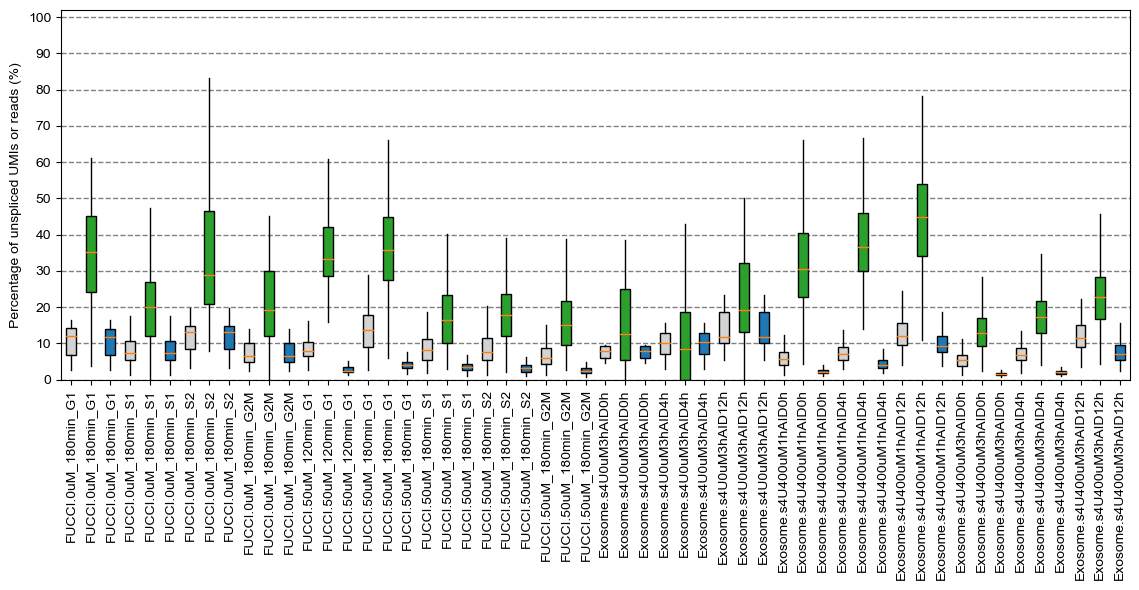

In [16]:
xs = np.arange(len(data))
xticks = [item[0] for item in data]
w = 0.5
plt.figure(figsize=(11.5, 6))
for x, item in zip(xs, data):
    name, group, vs = item
    if group == "New":
        color = "C2"
    elif group == "Old":
        color = "C0"
    else:
        color = "lightgrey"
    plt.boxplot([vs], positions=[x], widths=w, showcaps=False, showfliers=False,
                patch_artist=True, boxprops=dict(facecolor=color))
# plt.xticks([])
plt.xticks(xs, xticks, rotation=90)
# plt.xticks(xs, [item[1][0] for item in data], rotation=0, size=10)
plt.ylim(0, 102)
plt.yticks(np.arange(0, 101, 10))
plt.grid(axis="y", color="grey", lw=1, ls="--")
plt.ylabel("Percentage of unspliced UMIs or reads (%)")
plt.tight_layout()
# plt.savefig("figures/proportion_of_unspliced_reads.pdf")

0.05 1.3010299956639813


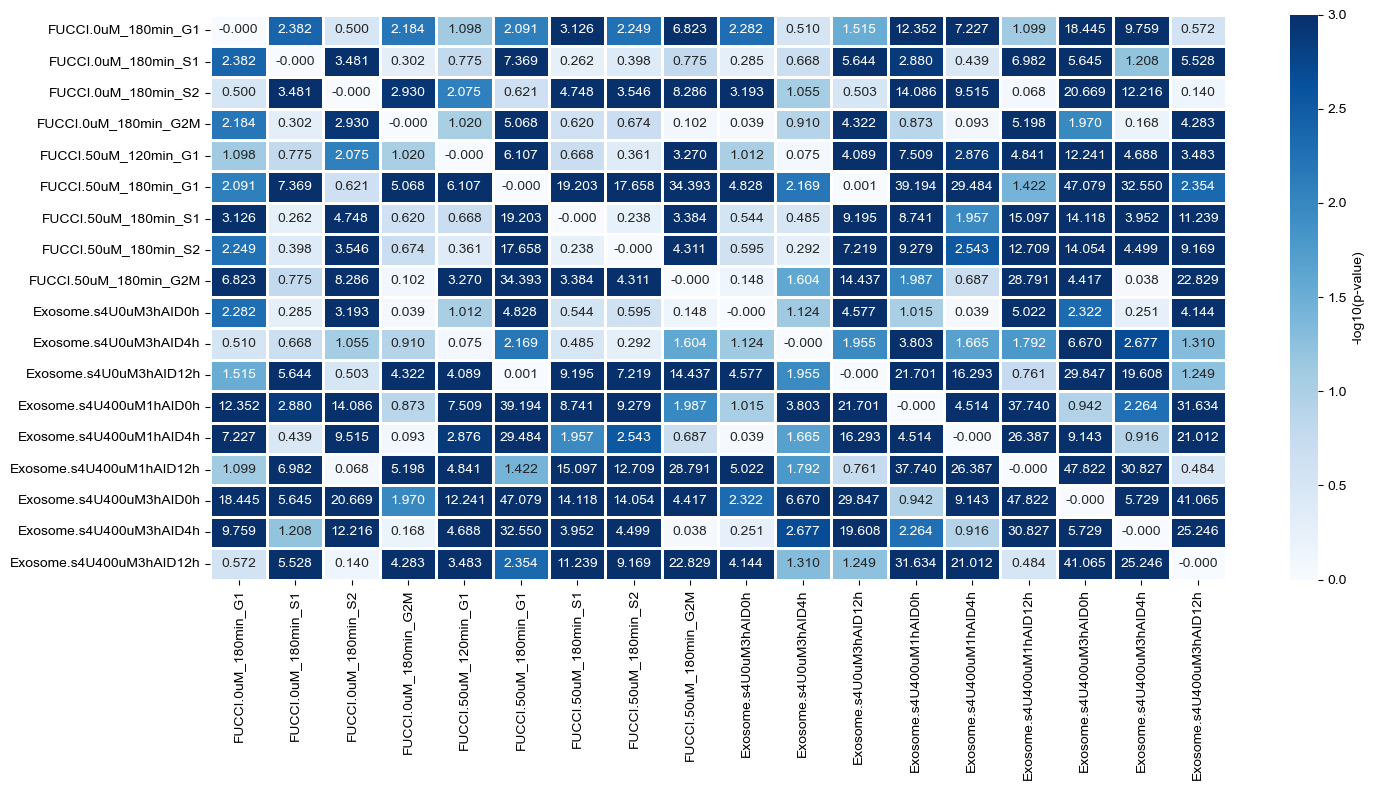

In [17]:
data1 = []
for item in data:
    if item[0].startswith("Public"):
        continue
    if item[1] == "All":
        data1.append(item)

names = [item[0] for item in data1]
M = np.zeros((len(data1), len(data1)))
for i in range(len(data1)):
    for j in range(len(data1)):
        vs1 = data1[i][2]
        vs2 = data1[j][2]
        M[i][j] = ttest_ind(vs1, vs2)[1]
M = pd.DataFrame(M, index=names, columns=names)

import seaborn as sns
print(0.05, -np.log10(0.05))
plt.figure(figsize=(15, 8))
sns.heatmap(-np.log10(M), cmap="Blues", annot=True, fmt=".3f", vmin=0, vmax=3, lw=1, color="white", cbar_kws=dict(label="-log10(p-value)"))
plt.tight_layout()
# plt.savefig("figures/ttest_unpliced_ratio.all.pdf")

# Proportion of unspliced RNAs (blastocyst)

In [29]:
data = []
info = pd.read_csv("../../0_Analysis_New/02_blastocyst/results/scanpy/Blastocyst.gene_based.clustered.obs.csv", index_col=0)
cts = ['ICM-1', 'ICM-2', 'EPI', 'PE', 'TE-1', 'TE-2', 'muralTE', 'polarTE']
for ct in cts:
    tmp = info[(info["CellType"] == ct) & (info["s4U"] == 400) & (info["Time"] == 3) & (info["ActD"].isna())]
    vs1 = []
    vs2 = []
    vs3 = []
    for cell in tmp.index:
        path = "../../1_NanoNASCseq/results/09_stat/01_read_location/%s/%s_summary.tsv" % (cell.split(".")[0], cell)
        n, p1, p2, p3 = load_unsplice_ratio(path)
        if n > 5000:
            vs1.append(p1)
            vs2.append(p2)
            vs3.append(p3)
    print(len(vs1))
    data.append(["%s.%s" % (ct, group), "All", vs1])
    data.append(["%s.%s" % (ct, group), "New", vs2])
    data.append(["%s.%s" % (ct, group), "Old", vs3])

195
354
206
118
159
170
108
115


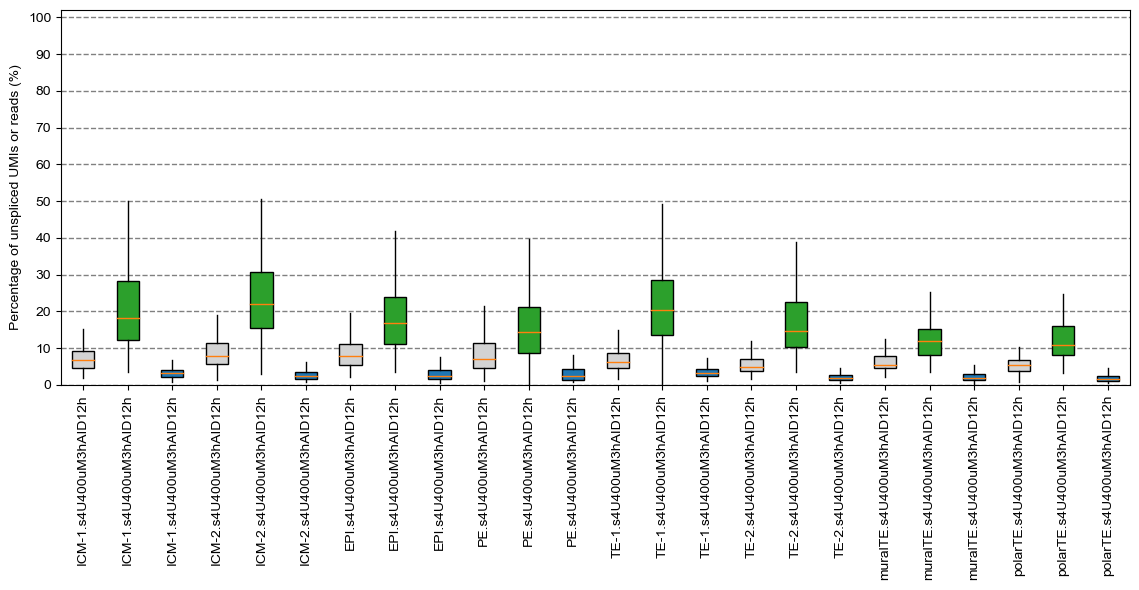

In [30]:
xs = np.arange(len(data))
xticks = [item[0] for item in data]
w = 0.5
plt.figure(figsize=(11.5, 6))
for x, item in zip(xs, data):
    name, group, vs = item
    if group == "New":
        color = "C2"
    elif group == "Old":
        color = "C0"
    else:
        color = "lightgrey"
    plt.boxplot([vs], positions=[x], widths=w, showcaps=False, showfliers=False,
                patch_artist=True, boxprops=dict(facecolor=color))
# plt.xticks([])
plt.xticks(xs, xticks, rotation=90)
# plt.xticks(xs, [item[1][0] for item in data], rotation=0, size=10)
plt.ylim(0, 102)
plt.yticks(np.arange(0, 101, 10))
plt.grid(axis="y", color="grey", lw=1, ls="--")
plt.ylabel("Percentage of unspliced UMIs or reads (%)")
plt.tight_layout()
# plt.savefig("figures/proportion_of_unspliced_reads.pdf")

0.05 1.3010299956639813


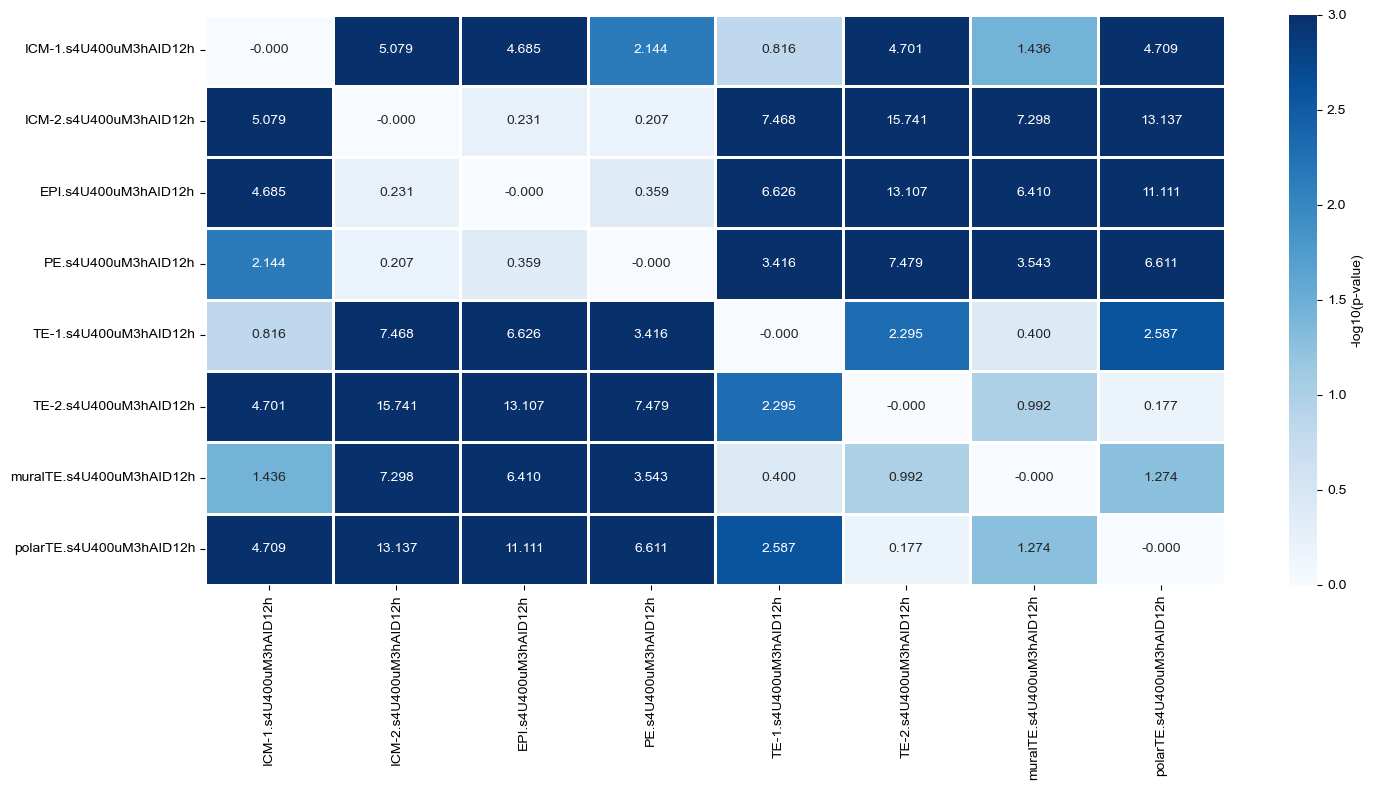

In [31]:
data1 = []
for item in data:
    if item[0].startswith("Public"):
        continue
    if item[1] == "All":
        data1.append(item)

names = [item[0] for item in data1]
M = np.zeros((len(data1), len(data1)))
for i in range(len(data1)):
    for j in range(len(data1)):
        vs1 = data1[i][2]
        vs2 = data1[j][2]
        M[i][j] = ttest_ind(vs1, vs2)[1]
M = pd.DataFrame(M, index=names, columns=names)

import seaborn as sns
print(0.05, -np.log10(0.05))
plt.figure(figsize=(15, 8))
sns.heatmap(-np.log10(M), cmap="Blues", annot=True, fmt=".3f", vmin=0, vmax=3, lw=1, color="white", cbar_kws=dict(label="-log10(p-value)"))
plt.tight_layout()
# plt.savefig("figures/ttest_unpliced_ratio.all.pdf")

# Enrichment of unspliced RNAs

In [2]:
import glob
import gzip
from collections import defaultdict
import pysam

In [9]:
n = 0
for time in [15, 30, 60, 120, 180]:
    for path in sorted(glob.glob("../../1_NanoNASCseq/results/09_stat/01_read_location/*/*.K562_s4U_*uM_%dmin.bed.gz" % time)):
        # if "Mix" in path:
        #     continue
        n += 1
n

737

In [25]:
data = defaultdict(list)
with open("results/unspliced_umis.bed", "w+") as fw:
    for time in [15, 30, 60, 120, 180]:
        # if time != 180:
        #     continue
        for path in sorted(glob.glob("../../1_NanoNASCseq/results/09_stat/01_read_location/*/*.K562_s4U_50uM_%dmin.bed.gz" % time)):
            if "Mix" in path:
                continue
            cell = path.split("/")[-1][:-7]
            # print(cell)
            n = 0
            with gzip.open(path, "rt") as f:
                for line in f:
                    row = line.strip("\n").split("\t")
                    chrom, start, end, name, score, strand, is_nascent, cats = row
                    if cats == "":
                        cats = []
                    else:
                        cats = cats.split(",")
                    if is_nascent == "True" or True:
                        if len(cats) == 0:
                            continue # unknown
                        if "exon-exon" in cats:
                            continue # spliced
                        if "exon" in cats:
                            continue # ambigious
                        data[cell].append(name)
                        fw.write("\t".join([chrom, start, end, "%s:%s" % (cell, name)]) + "\n")
                        n += 1
            print(n, cell, sep="\t")

275	20220719_K562_1.C01.K562_s4U_50uM_15min
601	20220719_K562_1.C02.K562_s4U_50uM_15min
1016	20220719_K562_1.C03.K562_s4U_50uM_15min
1105	20220719_K562_1.C04.K562_s4U_50uM_15min
152	20220719_K562_1.C05.K562_s4U_50uM_15min
237	20220719_K562_1.C06.K562_s4U_50uM_15min
710	20220719_K562_1.C07.K562_s4U_50uM_15min
337	20220719_K562_1.C08.K562_s4U_50uM_15min
909	20220719_K562_1.C09.K562_s4U_50uM_15min
864	20220719_K562_1.C10.K562_s4U_50uM_15min
659	20220719_K562_1.C11.K562_s4U_50uM_15min
1584	20220719_K562_1.C12.K562_s4U_50uM_15min
1415	20220719_K562_1.C13.K562_s4U_50uM_15min
248	20220719_K562_1.C14.K562_s4U_50uM_15min
295	20220719_K562_1.C15.K562_s4U_50uM_15min
636	20220719_K562_1.C16.K562_s4U_50uM_15min
280	20220719_K562_1.C17.K562_s4U_50uM_15min
424	20220719_K562_1.C18.K562_s4U_50uM_15min
1141	20220719_K562_1.C19.K562_s4U_50uM_15min
911	20220719_K562_1.C20.K562_s4U_50uM_15min
882	20220719_K562_1.C21.K562_s4U_50uM_15min
1189	20220719_K562_1.C22.K562_s4U_50uM_15min
161	20220719_K562_1.C23.K5

In [27]:
! sort -k1,1 -k2,2n results/unspliced_umis.bed | bgzip -c > results/unspliced_umis.bed.gz
! tabix -p bed results/unspliced_umis.bed.gz
! rm results/unspliced_umis.bed

In [35]:
outfile = "results/unspliced_umis.bam"
fw = None
for cell, names in data.items():
    names = set(names)
    bamfile = "../../1_NanoNASCseq/results/03_mapping/06_mark_duplicate/%s/%s.bam" % (cell.split(".")[0], cell)
    with pysam.AlignmentFile(bamfile) as f:
        if fw is None:
            fw = pysam.AlignmentFile(outfile, "wb", f)
        for s in f:
            if s.get_tag("CN") in names:
                fw.write(s)
fw.close()

[W::hts_idx_load3] The index file is older than the data file: ../../1_NanoNASCseq/results/03_mapping/06_mark_duplicate/20220719_K562_1/20220719_K562_1.C01.K562_s4U_50uM_15min.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../../1_NanoNASCseq/results/03_mapping/06_mark_duplicate/20220719_K562_1/20220719_K562_1.C02.K562_s4U_50uM_15min.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../../1_NanoNASCseq/results/03_mapping/06_mark_duplicate/20220719_K562_1/20220719_K562_1.C03.K562_s4U_50uM_15min.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../../1_NanoNASCseq/results/03_mapping/06_mark_duplicate/20220719_K562_1/20220719_K562_1.C04.K562_s4U_50uM_15min.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../../1_NanoNASCseq/results/03_mapping/06_mark_duplicate/20220719_K562_1/20220719_K562_1.C05.K562_s4U_50uM_15min.bam.bai
[W::hts_idx_load3] The index file is older than the data file: ../../1_NanoNASCs

In [36]:
! samtools sort -@ 4 -o results/unspliced_umis.sorted.bam results/unspliced_umis.bam
! samtools index -@ 4 results/unspliced_umis.sorted.bam

[bam_sort_core] merging from 0 files and 4 in-memory blocks...


# intron_retained and unspliced reads

In [21]:
from pyBioInfo.IO.File import BedFile, BamFile
from pyBioInfo.Utils import ShiftLoader

In [54]:
with BedFile("/home/chenzonggui/species/homo_sapiens/GRCh38.p13/gencode.v39.annotation.genes.bed.gz") as f:
    genes = []
    for g in f:
        g.count = 0
        genes.append(g)

In [55]:
loader = ShiftLoader(genes)
with BamFile("results/unspliced_umis.sorted.bam", random=True) as f:
    for align in f:
        if align.segment.is_duplicate:
            continue
        for g in loader.fetch(obj=align):
            if  g.strand == align.strand:
                g.count += 1

In [56]:
with open("results/gene_unspliced_count.tsv", "w+") as fw:
    fw.write("GeneID\tCount\n")
    for g in genes:
        fw.write("\t".join(map(str, [g.name, g.count])) + "\n")

In [67]:
m1 = pd.read_csv("results/gene_unspliced_count.tsv", sep="\t", index_col=0)
m1.columns = ["GeneUnsplicedUMIs"]
m2 = pd.read_csv("../07_halflife/results/expression_of_isoform_K562.tsv", sep="\t", index_col=0)
m = m2.merge(m1, left_on="GeneID", right_index=True)
# m = m[m["TranscriptType"] == "retained_intron"]
# m = m[m["Total"] > 50]
m = m[m["GeneUnsplicedUMIs"] > 50]
m = m.sort_values(by="GeneUnsplicedUMIs", ascending=False)
m.head(50)

,Total,TPM,TranscriptType,GeneID,GeneType,GeneName,Chrom,Start,End,Strand,Expressed,GeneUnsplicedUMIs
TranscriptID,,,,,,,,,,,,
ENST00000426413.2,16,9.472702,lncRNA,ENSG00000225546.6,lncRNA,LINC02476,chr7,119750808,119907397,-,False,762
ENST00000336906.6,31345,18557.615342,protein_coding,ENSG00000196565.15,protein_coding,HBG2,chr11,5253187,5254781,-,True,649
ENST00000444587.1,62,36.706720,protein_coding,ENSG00000196565.15,protein_coding,HBG2,chr11,5253388,5254741,-,True,649
ENST00000643199.1,1,0.592044,processed_transcript,ENSG00000239920.2,protein_coding,ENSG00000239920,chr11,5254897,5345861,-,False,640
ENST00000380259.7,18,10.656790,nonsense_mediated_decay,ENSG00000239920.2,protein_coding,ENSG00000239920,chr11,5254391,5678434,-,True,640
ENST00000380237.5,8,4.736351,protein_coding,ENSG00000213931.7,protein_coding,HBE1,chr11,5268344,5505604,-,False,609
ENST00000415970.6,296,175.244988,processed_transcript,ENSG00000167355.8,protein_coding,OR51B5,chr11,5340324,5505652,-,True,516
ENST00000418729.1,30,17.761316,non_stop_decay,ENSG00000167355.8,protein_coding,OR51B5,chr11,5342941,5505652,-,True,516
ENST00000420465.6,1,0.592044,processed_transcript,ENSG00000167355.8,protein_coding,OR51B5,chr11,5305166,5505613,-,False,516


# 2025-03-20

In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
array = []
for path in glob.glob("../../../1_NanoNASCseq/results/09_stat/01_read_location/*/*.K562_s4U_50uM_15min_summary.tsv"):
    array.append(pd.read_csv(path, sep="\t"))

In [7]:
m = pd.concat(array, ignore_index=True)

In [9]:
m = m[m["Group"] == "New"]

Mean: 0.6048311982005985
Median: 0.6441612048941427


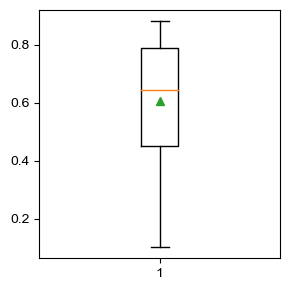

In [17]:
vs = m["UnsplicedRatio"]
print("Mean:", np.mean(vs))
print("Median:", np.median(vs))
plt.figure(figsize=(3, 3))
plt.boxplot(vs, showmeans=True)
plt.tight_layout()
plt.show()
plt.close()

Mean: 192.9375
Median: 133.5


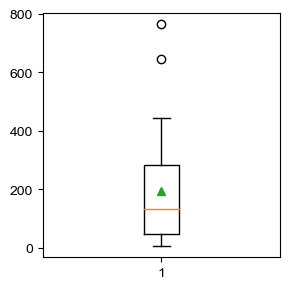

In [18]:
vs = m["Unspliced"]
print("Mean:", np.mean(vs))
print("Median:", np.median(vs))
plt.figure(figsize=(3, 3))
plt.boxplot(vs, showmeans=True)
plt.tight_layout()
plt.show()
plt.close()

# 2025-03-23

In [7]:
info = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")
info = info[(info["CellLine"] == "K562") & (info["s4U"] == 50) & (info["Time"] == 0.25)]
print(info.shape)

(32, 54)


In [20]:
array = []
for run, cell in info[["Run", "Cell"]].values:
    path = "../../../1_NanoNASCseq/results/09_stat/01_read_location/%s/%s_summary.tsv" % (run, cell)
    d = pd.read_csv(path, sep="\t")
    array.append(d)
m = pd.concat(array, ignore_index=True)
m = m[m["Group"] == "New"]

In [26]:
print("K562 50uM, 15 min")
print("Cells:", info.shape[0])

rows = []

vs = info["UMIs"]
rows.append([np.mean(vs), np.median(vs), np.sum(vs)])
vs = info["mrUMIs"]
rows.append([np.mean(vs), np.median(vs), np.sum(vs)])
vs = info["mrUMIs.New"]
rows.append([np.mean(vs), np.median(vs), np.sum(vs)])
vs = m["Spliced"]
rows.append([np.mean(vs), np.median(vs), np.sum(vs)])
vs = m["Unspliced"]
rows.append([np.mean(vs), np.median(vs), np.sum(vs)])

d = pd.DataFrame(rows)
d.index=["UMIs", "mrUMIs", "New mrUMIs", "New mrUMIs (spliced)", "New mrUMIs (unspliced)"]
d.columns = ["Mean", "Median", "Sum"]
d

K562 50uM, 15 min
Cells: 32


,Mean,Median,Sum
UMIs,18108.31250,17215.5,579466
mrUMIs,10372.59375,10068.5,331923
New mrUMIs,477.90625,382.0,15293
New mrUMIs (spliced),70.71875,66.5,2263
New mrUMIs (unspliced),192.93750,133.5,6174


# 2025-03-26

In [67]:
def stat(cl, s4u, time):
    info = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")
    info = info[(info["CellLine"] == cl) & (info["s4U"] == s4u) & (info["Time"] == time) & (info["ActD"].isna()) & (info["UMIs"] > 5000)]
    # print(info.shape)
    
    array = []
    for run, cell in info[["Run", "Cell"]].values:
        path = "../../../1_NanoNASCseq/results/09_stat/01_read_location/%s/%s_summary.tsv" % (run, cell)
        d = pd.read_csv(path, sep="\t")
        array.append(d)
    m = pd.concat(array, ignore_index=True)
    m = m[m["Group"] == "New"]

    print("Cell line:", cl)
    print("Condition: %d uM, %.2f h" % (s4u, time))
    print("Cells:", info.shape[0])
    
    rows = []
    
    vs = info["UMIs"]
    rows.append([np.mean(vs), np.median(vs), np.sum(vs)])
    vs = info["mrUMIs"]
    rows.append([np.mean(vs), np.median(vs), np.sum(vs)])
    vs = info["mrUMIs.New"]
    rows.append([np.mean(vs), np.median(vs), np.sum(vs)])
    vs = m["Spliced"]
    rows.append([np.mean(vs), np.median(vs), np.sum(vs)])
    vs = m["Unspliced"]
    rows.append([np.mean(vs), np.median(vs), np.sum(vs)])
    
    d = pd.DataFrame(rows)
    d.index=["UMIs", "mrUMIs", "New mrUMIs", "New mrUMIs (spliced)", "New mrUMIs (unspliced)"]
    d.columns = ["Mean", "Median", "Sum"]
    return d

In [73]:
stat("K562", 0, 3)

Cell line: K562
Condition: 0 uM, 3.00 h
Cells: 190


,Mean,Median,Sum
UMIs,15366.384211,15022.5,2919613
mrUMIs,8904.631579,8851.0,1691880
New mrUMIs,33.305263,24.0,6328
New mrUMIs (spliced),5.605263,5.0,1065
New mrUMIs (unspliced),3.763158,3.0,715


In [68]:
stat("K562", 50, 0.25)

Cell line: K562
Condition: 50 uM, 0.25 h
Cells: 32


,Mean,Median,Sum
UMIs,18108.31250,17215.5,579466
mrUMIs,10372.59375,10068.5,331923
New mrUMIs,477.90625,382.0,15293
New mrUMIs (spliced),70.71875,66.5,2263
New mrUMIs (unspliced),192.93750,133.5,6174


In [69]:
stat("K562", 50, 0.5)

Cell line: K562
Condition: 50 uM, 0.50 h
Cells: 51


,Mean,Median,Sum
UMIs,20544.960784,20033.0,1047793
mrUMIs,11692.254902,11646.0,596305
New mrUMIs,556.470588,447.0,28380
New mrUMIs (spliced),120.980392,106.0,6170
New mrUMIs (unspliced),177.274510,103.0,9041


In [70]:
stat("K562", 50, 1)

Cell line: K562
Condition: 50 uM, 1.00 h
Cells: 41


,Mean,Median,Sum
UMIs,12374.926829,12815.0,507372
mrUMIs,6926.487805,6916.0,283986
New mrUMIs,365.000000,286.0,14965
New mrUMIs (spliced),129.170732,121.0,5296
New mrUMIs (unspliced),78.487805,48.0,3218


In [71]:
stat("K562", 50, 2)

Cell line: K562
Condition: 50 uM, 2.00 h
Cells: 44


,Mean,Median,Sum
UMIs,14781.090909,14077.5,650368
mrUMIs,8222.431818,7890.5,361787
New mrUMIs,565.636364,410.0,24888
New mrUMIs (spliced),266.000000,202.0,11704
New mrUMIs (unspliced),61.272727,38.0,2696


In [72]:
stat("K562", 50, 3)

Cell line: K562
Condition: 50 uM, 3.00 h
Cells: 179


,Mean,Median,Sum
UMIs,13339.016760,12220.0,2387684
mrUMIs,7874.960894,7339.0,1409618
New mrUMIs,951.787709,824.0,170370
New mrUMIs (spliced),485.620112,422.0,86926
New mrUMIs (unspliced),82.279330,61.0,14728


In [74]:
stat("mESC", 0, 3)

Cell line: mESC
Condition: 0 uM, 3.00 h
Cells: 64


,Mean,Median,Sum
UMIs,15208.937500,14726.0,973372
mrUMIs,9311.156250,9192.5,595914
New mrUMIs,77.062500,65.0,4932
New mrUMIs (spliced),17.812500,15.0,1140
New mrUMIs (unspliced),3.703125,3.0,237


In [75]:
stat("mESC", 400, 3)

Cell line: mESC
Condition: 400 uM, 3.00 h
Cells: 112


,Mean,Median,Sum
UMIs,10251.142857,9671.5,1148128
mrUMIs,6373.080357,6014.5,713785
New mrUMIs,2976.125000,2765.0,333326
New mrUMIs (spliced),1571.339286,1461.0,175990
New mrUMIs (unspliced),205.517857,164.5,23018
